In [3]:
import os
import numpy as np 
import pandas as pd
from PIL import Image

In [4]:
cur_path = os.getcwd()
data_folder = '../data/'
classes_count = 43
height = 32
width = 32
channels = 3

In [5]:
classes = { 1:'Speed limit (20km/h)',
            2:'Speed limit (30km/h)', 
            3:'Speed limit (50km/h)', 
            4:'Speed limit (60km/h)', 
            5:'Speed limit (70km/h)', 
            6:'Speed limit (80km/h)', 
            7:'End of speed limit (80km/h)', 
            8:'Speed limit (100km/h)', 
            9:'Speed limit (120km/h)', 
            10:'No passing', 
            11:'No passing veh over 3.5 tons', 
            12:'Right-of-way at intersection', 
            13:'Priority road', 
            14:'Yield', 
            15:'Stop', 
            16:'No vehicles', 
            17:'Veh > 3.5 tons prohibited', 
            18:'No entry', 
            19:'General caution', 
            20:'Dangerous curve left', 
            21:'Dangerous curve right', 
            22:'Double curve', 
            23:'Bumpy road', 
            24:'Slippery road', 
            25:'Road narrows on the right', 
            26:'Road work', 
            27:'Traffic signals', 
            28:'Pedestrians', 
            29:'Children crossing', 
            30:'Bicycles crossing', 
            31:'Beware of ice/snow',
            32:'Wild animals crossing', 
            33:'End speed + passing limits', 
            34:'Turn right ahead', 
            35:'Turn left ahead', 
            36:'Ahead only', 
            37:'Go straight or right', 
            38:'Go straight or left', 
            39:'Keep right', 
            40:'Keep left', 
            41:'Roundabout mandatory', 
            42:'End of no passing', 
            43:'End no passing veh > 3.5 tons' }

In [20]:
# Load training data
# Downloaded from : https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
# Assuming that data is located in ../data/train/ with folder names ranging from 0 to classes-1, with no padding
# Since the images are of different shapes, they will be resized to (32, 32)
train_data = []
train_labels = []

for i in range(classes_count):
    folder = os.path.join(data_folder, 'train', str(i))
    images = os.listdir(folder)
    
    for file in images:
        try:
            image = Image.open(os.path.join(folder, file))
            image = image.resize((height, width))
            train_data.append(np.array(image))
            train_labels.append(i)
        # Handle any errors during the process (e.g. each folder containing additional csv file)
        except Exception as e:
            print("Error loading image:", file, e )


In [21]:
X_train = np.array(train_data)
X_train.shape

(39209, 32, 32, 3)

In [22]:
labels_count = dict(zip(*np.unique(train_labels, return_counts=True)))
print(labels_count)

{0: 210, 1: 2220, 2: 2250, 3: 1410, 4: 1980, 5: 1860, 6: 420, 7: 1440, 8: 1410, 9: 1470, 10: 2010, 11: 1320, 12: 2100, 13: 2160, 14: 780, 15: 630, 16: 420, 17: 1110, 18: 1200, 19: 210, 20: 360, 21: 330, 22: 390, 23: 510, 24: 270, 25: 1500, 26: 600, 27: 240, 28: 540, 29: 270, 30: 450, 31: 780, 32: 240, 33: 689, 34: 420, 35: 1200, 36: 390, 37: 210, 38: 2070, 39: 300, 40: 360, 41: 240, 42: 240}


In [23]:
np.bincount(train_labels)

array([ 210, 2220, 2250, 1410, 1980, 1860,  420, 1440, 1410, 1470, 2010,
       1320, 2100, 2160,  780,  630,  420, 1110, 1200,  210,  360,  330,
        390,  510,  270, 1500,  600,  240,  540,  270,  450,  780,  240,
        689,  420, 1200,  390,  210, 2070,  300,  360,  240,  240])

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, train_labels, test_size=0.2) 

In [25]:
y_train = np.array(y_train)
y_val = np.array(y_val)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# To prevent overfitting the training will be stopped if the val_loss has not decreased in 5 epochs
earlystop = EarlyStopping(patience=5) 

# Decrease learning rate if the accuracy is not increased for 2 steps
learning_rate_reduction = ReduceLROnPlateau(monitor='val_sparse_categorical_accuracy', 
                                            patience=2, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)

callbacks = [earlystop, learning_rate_reduction]

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization, Flatten, Dense


def create_model():
    model = Sequential()

    # Add layers
    model.add(Conv2D(64, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
    model.add(Dropout(0.25))

    model.add(BatchNormalization(input_shape=(height, width, channels)))
    model.add(Conv2D(128, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(BatchNormalization(input_shape=(height, width, channels)))
    model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(classes_count, activation='softmax'))
    return model

In [28]:
model = create_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

In [29]:
history = model.fit(
    X_train.astype(np.float32),
    y_train.astype(np.float32),
    validation_data=(X_val.astype(np.float32), y_val.astype(np.float32)),
    validation_freq=1,
    epochs=40,
    callbacks=callbacks
)

Train on 31367 samples, validate on 7842 samples
Epoch 1/40
31367/31367 [==============================] - 14s 461us/sample - loss: 3.1134 - sparse_categorical_accuracy: 0.1239 - val_loss: 2.4241 - val_sparse_categorical_accuracy: 0.2721
Epoch 2/40
31367/31367 [==============================] - 12s 392us/sample - loss: 2.7420 - sparse_categorical_accuracy: 0.1871 - val_loss: 2.1020 - val_sparse_categorical_accuracy: 0.3840
Epoch 3/40
31367/31367 [==============================] - 12s 389us/sample - loss: 2.2685 - sparse_categorical_accuracy: 0.3160 - val_loss: 1.5712 - val_sparse_categorical_accuracy: 0.4903
Epoch 4/40
31367/31367 [==============================] - 12s 387us/sample - loss: 1.3005 - sparse_categorical_accuracy: 0.5929 - val_loss: 0.4800 - val_sparse_categorical_accuracy: 0.8444
Epoch 5/40
31367/31367 [==============================] - 12s 386us/sample - loss: 0.5060 - sparse_categorical_accuracy: 0.8449 - val_loss: 0.1249 - val_sparse_categorical_accuracy: 0.9644
Epoch 

In [30]:
test_labels = pd.read_csv(os.path.join(data_folder, 'test.csv'))['ClassId']

In [31]:
test_labels

0        16
1         1
2        38
3        33
4        11
         ..
12625    12
12626    33
12627     6
12628     7
12629    10
Name: ClassId, Length: 12630, dtype: int64

In [32]:
# Load test data
test_data = []

folder = os.path.join(data_folder, 'test')
images = sorted(os.listdir(folder))

for file in images:
    try:
        image = Image.open(os.path.join(folder, file))
        image = image.resize((height, width))
        test_data.append(np.array(image))
    # Handle any errors during the process (e.g. each folder containing additional csv file)
    except Exception as e:
        print("Error loading image:", file, e )


Error loading image: GT-final_test.csv cannot identify image file '../data/test/GT-final_test.csv'


In [33]:
X_test = np.array(test_data, dtype=np.float32)
X_test.shape

(12630, 32, 32, 3)

In [34]:
predictions = model.predict(X_test)

In [35]:
predictions = np.argmax(predictions, axis=1)

In [36]:
predictions

array([16,  1, 38, ...,  5,  7, 10])

In [37]:
result = (predictions == test_labels)
result

0         True
1         True
2         True
3         True
4         True
         ...  
12625     True
12626     True
12627    False
12628     True
12629     True
Name: ClassId, Length: 12630, dtype: bool

In [38]:
result.value_counts()

True     12296
False      334
Name: ClassId, dtype: int64

In [39]:
predictions[result==False]

array([26, 23, 26,  1, 24,  5, 40,  1, 20, 36,  3, 10,  5,  5,  5,  5, 42,
        1,  8, 26, 42,  4, 25, 27, 25, 32, 40, 21, 26, 25, 11, 26,  4, 25,
       15, 28,  5, 11,  8,  8,  9,  2, 25,  5,  2, 11,  5,  1, 26, 27, 31,
        8, 38, 25, 42, 15,  8, 19,  1,  2, 31, 18, 20,  5, 31,  1,  5,  5,
       19,  1, 40,  8, 40, 25, 27, 10,  5, 25,  2,  9, 42, 13,  5, 42, 25,
        5, 19, 31, 40, 42,  5,  7, 25, 26,  2, 30,  9, 15, 35, 25, 40, 15,
       10, 20,  8, 42, 19, 23,  1,  9, 11, 11, 36, 23,  5, 20,  5,  1,  5,
       25,  5, 27, 25, 26,  5,  3, 40,  5, 21, 31,  7, 30,  2, 26, 29, 30,
       10,  3, 15, 21, 31, 15, 25,  8, 11, 20,  5, 26, 20,  5, 19, 11,  2,
       25, 25,  5,  6, 25, 31, 20,  3,  8, 20, 25, 11, 42,  5, 42,  5,  5,
        9, 42,  5, 26,  7, 31, 25,  9,  2, 42, 25,  5, 25, 31, 26, 31,  5,
        3, 33,  5,  8, 20, 19, 21,  8,  8, 25,  5, 25, 13, 27,  8,  5,  5,
       42, 26, 25, 20, 37, 42, 26,  4,  8, 31, 20, 13,  8, 26, 31,  5,  5,
        5,  3,  0, 42, 21

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns 

Text(123.0, 0.5, 'Actual')

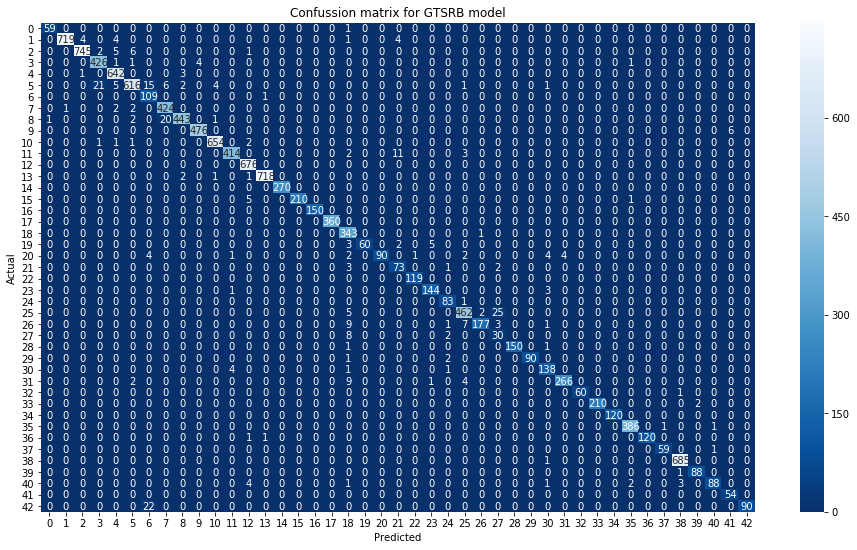

In [41]:
matrix = confusion_matrix(predictions, test_labels)
plt.figure(figsize=(16,9))
sns.heatmap(matrix, annot=True, fmt="d", cmap='Blues_r')
plt.title('Confussion matrix for GTSRB model')
plt.xlabel('Predicted')
plt.ylabel('Actual')